In [1]:
# Load necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import xgboost as xgb

# Unsupervised learning (Breast Cancer) 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Regression (Bank Marketing) models & metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Classification (Bank Marketing) models & metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, 
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score, roc_curve, auc
)

In [2]:
## Unsupervised Learning (Breast Cancer METABRIC)

In [3]:
# Apply random seed for reproducibility
np.random.seed(42) 

In [4]:
# Load unuspervised learning dataset
df_metabric = pd.read_csv(r"C:\Users\Maggy\Downloads\ST3189 Machine Learning\METABRIC_RNA_Mutation.csv")

C:\Users\Maggy\AppData\Local\Temp\ipykernel_19648\2403654654.py:2: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  df_metabric = pd.read_csv(r"C:\Users\Maggy\Downloads\ST3189 Machine Learning\METABRIC_RNA_Mutation.csv")


In [5]:
# Unusupervised learing dataset source:
# https://www.kaggle.com/datasets/raghadalharbi/breast-cancer-gene-expression-profiles-metabric?resource=download

In [6]:
df_metabric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Columns: 693 entries, patient_id to siah1_mut
dtypes: float64(498), int64(5), object(190)
memory usage: 10.1+ MB


In [7]:
df_metabric.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Check missing values
miss_values = df_metabric.isnull().sum().sort_values(ascending=False)
miss_values = miss_values[miss_values > 0]
miss_values_df = pd.DataFrame(miss_values, columns=['Missing Values'])
miss_values_df

,Missing Values
tumor_stage,501
3-gene_classifier_subtype,204
primary_tumor_laterality,106
neoplasm_histologic_grade,72
cellularity,54
mutation_count,45
er_status_measured_by_ihc,30
type_of_breast_surgery,22
tumor_size,20
cancer_type_detailed,15


In [9]:
# Data Summary
df_metabric.describe()

,patient_id,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,overall_survival_months,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
count,1904.000000,1904.000000,1904.000000,1904.000000,1832.000000,1904.000000,1904.000000,1859.000000,1904.000000,1904.000000,...,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03
mean,3921.982143,61.087054,0.207983,2.643908,2.415939,0.616597,2.002101,5.697687,4.033019,125.121324,...,4.726891e-07,-3.676471e-07,-9.453782e-07,-1.050420e-07,-0.000002,3.676471e-07,4.726891e-07,7.878151e-07,0.000000,3.731842e-18
std,2358.478332,12.978711,0.405971,1.228615,0.650612,0.486343,4.079993,4.058778,1.144492,76.334148,...,1.000263e+00,1.000262e+00,1.000262e+00,1.000263e+00,1.000262,1.000264e+00,1.000262e+00,1.000263e+00,1.000262,1.000262e+00
min,0.000000,21.930000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,-2.120800e+00,-3.364800e+00,-2.719400e+00,-4.982700e+00,-2.981700,-3.833300e+00,-3.609300e+00,-1.166900e+00,-2.112600,-1.051600e+00
25%,896.500000,51.375000,0.000000,1.000000,2.000000,0.000000,0.000000,3.000000,3.046000,60.825000,...,-6.188500e-01,-6.104750e-01,-6.741750e-01,-6.136750e-01,-0.632900,-6.664750e-01,-7.102000e-01,-5.058250e-01,-0.476200,-7.260000e-01
50%,4730.500000,61.770000,0.000000,3.000000,3.000000,1.000000,0.000000,5.000000,4.042000,115.616667,...,-2.456500e-01,-4.690000e-02,-1.422500e-01,-5.175000e-02,-0.026650,7.000000e-04,-2.980000e-02,-2.885500e-01,-0.133400,-4.248000e-01
75%,5536.250000,70.592500,0.000000,3.000000,3.000000,1.000000,2.000000,7.000000,5.040250,184.716667,...,3.306000e-01,5.144500e-01,5.146000e-01,5.787750e-01,0.590350,6.429000e-01,5.957250e-01,6.022500e-02,0.270375,4.284000e-01
max,7299.000000,96.290000,1.000000,5.000000,3.000000,1.000000,45.000000,80.000000,6.360000,355.200000,...,6.534900e+00,1.027030e+01,6.329000e+00,4.571300e+00,12.742300,3.938800e+00,3.833400e+00,1.088490e+01,12.643900,3.284400e+00


In [10]:
# Select features for clustering
selected_cluster_features = ['age_at_diagnosis', 'tumor_size', 'mutation_count','lymph_nodes_examined_positive', 'nottingham_prognostic_index']

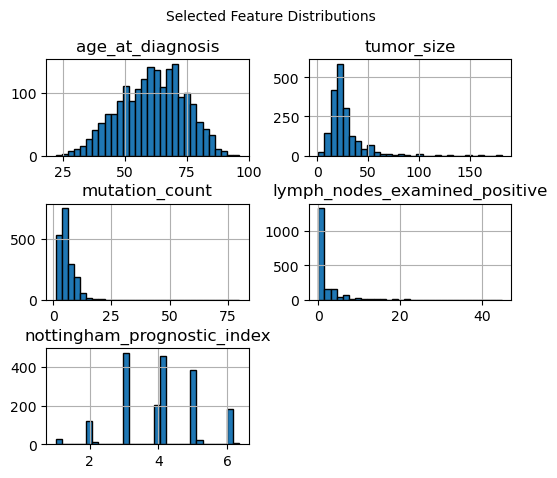

In [11]:
# Distributions of selected features
df_metabric[selected_cluster_features].hist(
    figsize=(6,5), 
    bins=30, 
    edgecolor='black'
)

plt.suptitle('Selected Feature Distributions', fontsize=10)
plt.subplots_adjust(hspace=0.5)  
plt.show()

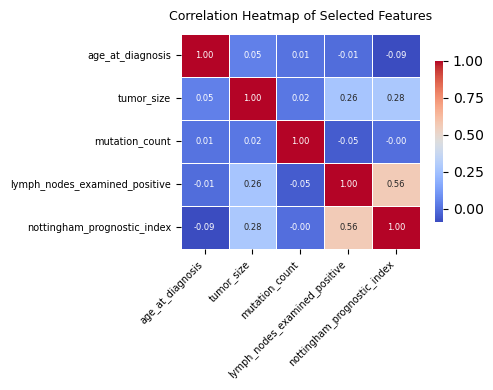

In [12]:
# Selected features correlation heatmap
plt.figure(figsize=(5, 4)) 

sns.heatmap(
    df_metabric[selected_cluster_features].corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},     
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": 0.75}  
)


plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)

plt.title('Correlation Heatmap of Selected Features', fontsize=9, pad=10)
plt.tight_layout()

plt.savefig("clear_correlationheatmap.png", dpi=300)
plt.show()

In [13]:
clustering_df_metabric = df_metabric[selected_cluster_features].copy()

In [14]:
print(clustering_df_metabric.isnull().sum())  
print(f"Total missing values: {clustering_df_metabric.isnull().sum().sum()}")
print(f"Total rows before cleaning: {clustering_df_metabric.shape[0]}") 

age_at_diagnosis                  0
tumor_size                       20
mutation_count                   45
lymph_nodes_examined_positive     0
nottingham_prognostic_index       0
dtype: int64
Total missing values: 65
Total rows before cleaning: 1904


In [15]:
# Drop missing values
valid_indices = clustering_df_metabric.dropna().index 
clustering_df = clustering_df_metabric.loc[valid_indices]  

In [16]:
df_clean = df_metabric.loc[valid_indices].copy()

In [17]:
# Data standardization
scaler = StandardScaler()
data_scaled = scaler.fit_transform(clustering_df)

In [18]:
# Apply PCA
pca = PCA() 
pca_result = pca.fit_transform(data_scaled)
explained_variance_ratio = pca.explained_variance_ratio_

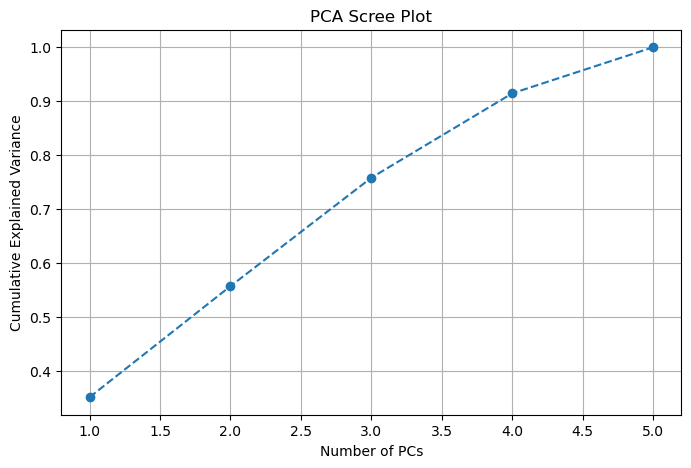

In [19]:
# Scree plot to determine the number of PC
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance_ratio) + 1), 
         np.cumsum(explained_variance_ratio), marker='o', linestyle='--')
plt.xlabel('Number of PCs')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.grid()
plt.show()

In [20]:
# Apply PCA to retain 95% variance
pca_95 = PCA(n_components=0.95)
pca_result_95 = pca_95.fit_transform(data_scaled)
print(f"Number of selected components: {pca_95.n_components_}")

Number of selected components: 5


In [21]:
print("\nexplained variance ratio by component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.3f}")


explained variance ratio by component:
PC1: 0.352
PC2: 0.206
PC3: 0.201
PC4: 0.156
PC5: 0.085


In [22]:
# Keep only 4 PCs
pca_4 = PCA(n_components=4)  
pca_result_4 = pca_4.fit_transform(data_scaled)

In [23]:
# Apply K-Means clustering K=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(pca_result_4) 

In [24]:
# Silhouette score for K=2
silhouette_avg = silhouette_score(pca_result_4, cluster_labels)
print(f"Silhouette Score K=2: {silhouette_avg:.3f}")

Silhouette Score K=2: 0.354


In [25]:
# Silhouette scores for K=2 to 10
silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(pca_result_4)
    silhouette_scores[k] = silhouette_score(pca_result_4, cluster_labels)

In [26]:
# Convert to DataFrame
silhouette_df = pd.DataFrame(list(silhouette_scores.items()), columns=["K", "Silhouette Score"])

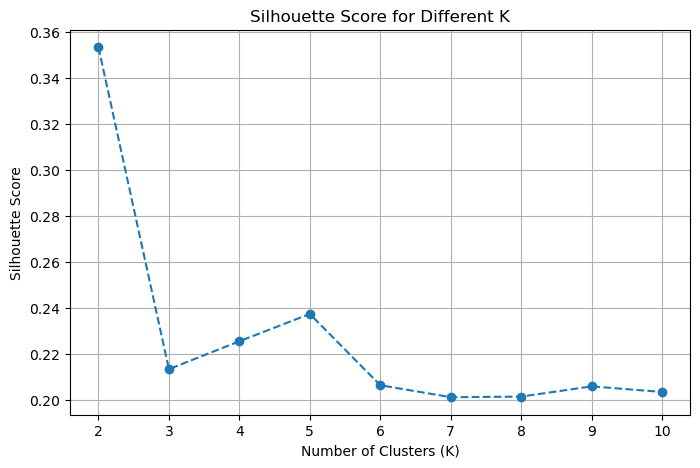

In [27]:
# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(silhouette_df["K"], silhouette_df["Silhouette Score"], marker='o', linestyle='--')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K")
plt.grid()
plt.show()

In [28]:
# Inertia (WCSS) for elbow method
inertia_values = []  

for k in range(1, 11):  
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_result_4)  
    inertia_values.append(kmeans.inertia_)

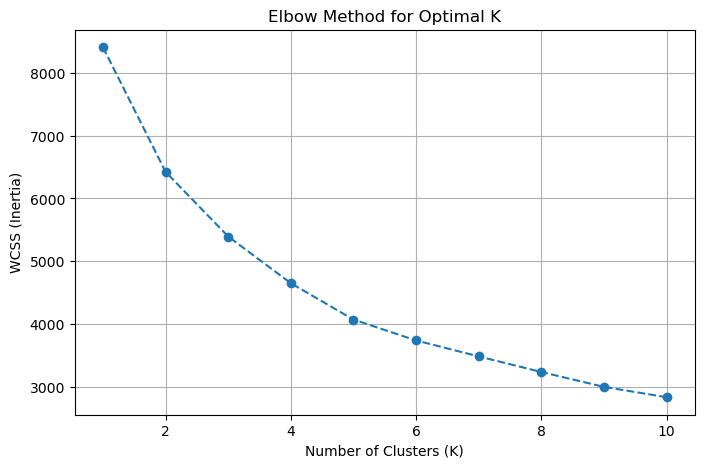

In [29]:
# Plot Elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia_values, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.grid()
plt.show()

In [30]:
# Apply K-Means with K=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(pca_result_4)

In [31]:
# Add cluster labels to dataset
clustering_df["Cluster"] = cluster_labels

In [32]:
# Display cluster distribution counts
print("Cluster distribution:\n", clustering_df["Cluster"].value_counts())

Cluster distribution:
 1    1465
0     374
Name: Cluster, dtype: int64


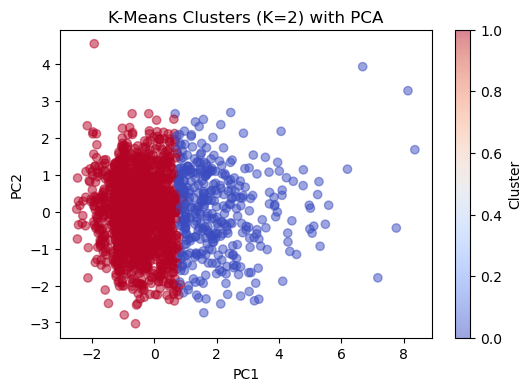

In [33]:
# Plot K-Means clustering
plt.figure(figsize=(6,4))
plt.scatter(pca_result_4[:, 0], pca_result_4[:, 1], c=cluster_labels, cmap='coolwarm', alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (K=2) with PCA")
plt.colorbar(label="Cluster")
plt.show()

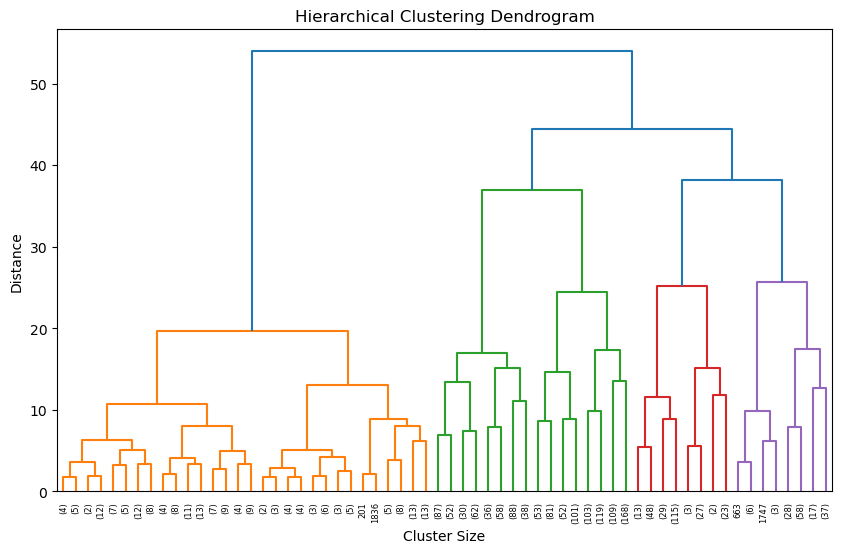

In [34]:
# Hierarchical clustering using Ward linkage
linked = linkage(pca_result_4, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='level', p=5, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

In [35]:
# Mean values of selected features for each cluster
cluster_analysis = clustering_df.groupby("Cluster").mean()
cluster_analysis

,age_at_diagnosis,tumor_size,mutation_count,lymph_nodes_examined_positive,nottingham_prognostic_index
Cluster,,,,,
0,60.825722,39.70385,5.679144,7.502674,5.477803
1,61.169126,22.89114,5.660751,0.587031,3.671721


In [36]:
# Calinski-Harabasz Score
ch_score = calinski_harabasz_score(pca_result_4, cluster_labels)
print(f"Calinski-Harabasz Score K=2: {ch_score:.2f}")

Calinski-Harabasz Score K=2: 568.18


<Figure size 600x400 with 0 Axes>

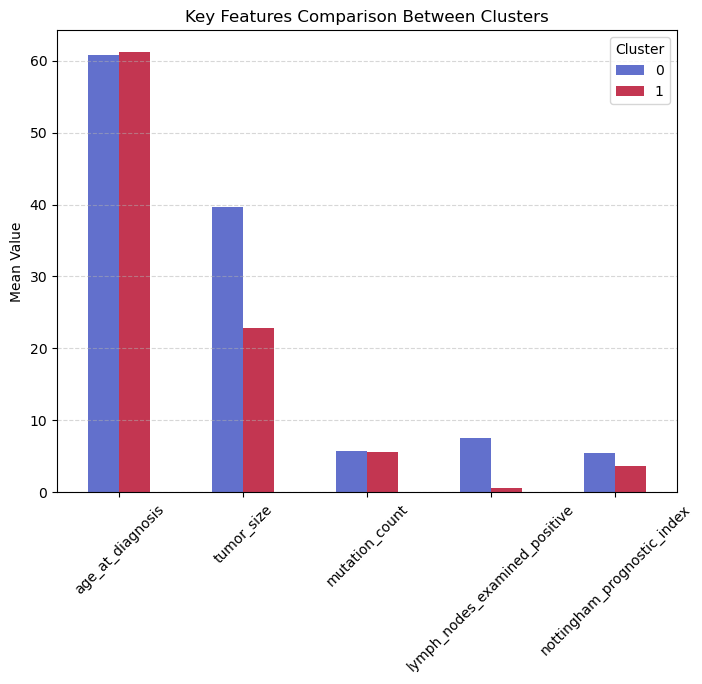

In [37]:
# Select key features to compare
features = ["age_at_diagnosis", "tumor_size", "mutation_count", "lymph_nodes_examined_positive", "nottingham_prognostic_index"]
cluster_means = clustering_df.groupby("Cluster")[features].mean()

plt.figure(figsize=(6,4))
cluster_means.T.plot(kind="bar", figsize=(8,6), colormap="coolwarm", alpha=0.8)
plt.title("Key Features Comparison Between Clusters")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

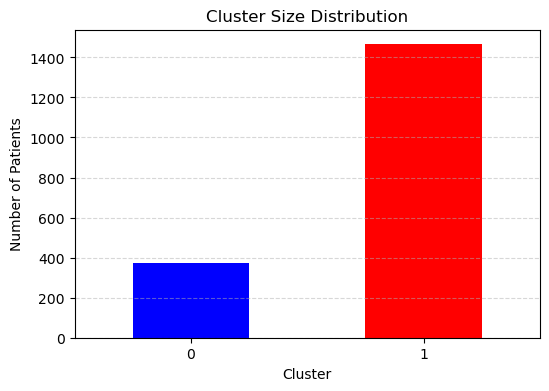

In [38]:
# Display cluster size distribution
plt.figure(figsize=(6,4))
cluster_size = clustering_df["Cluster"].value_counts().sort_index()
cluster_size.plot(kind="bar", color=["blue", "red"])
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [39]:
np.bincount(cluster_labels)

array([ 374, 1465], dtype=int64)

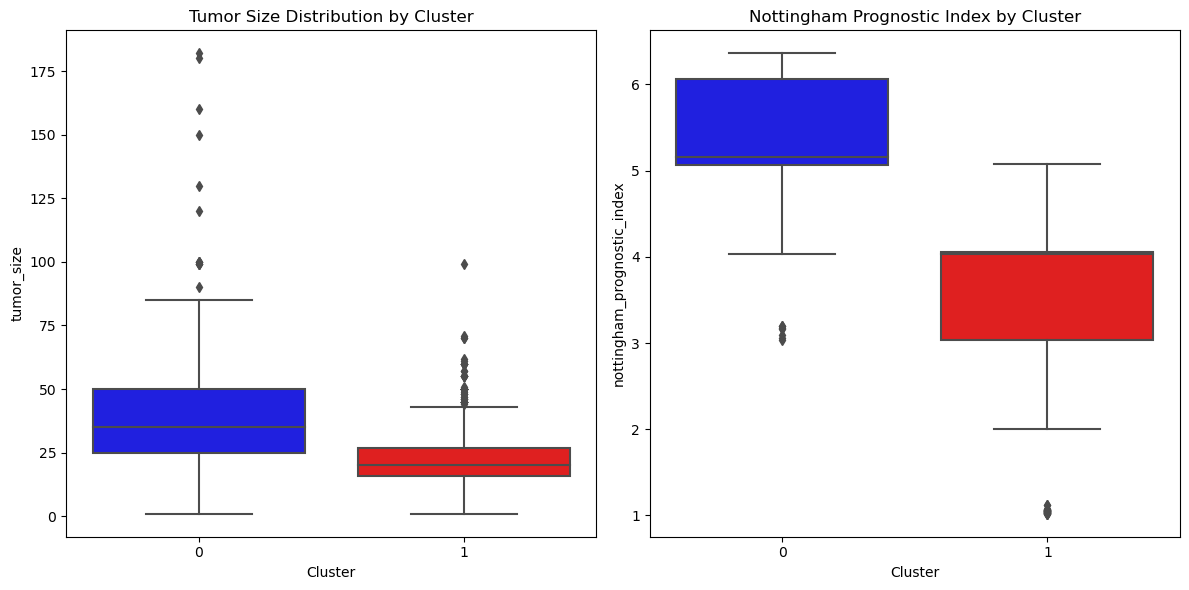

In [40]:
# Display Boxplot for tumor size and Nottingham Nottingham Prognostic Index
plt.figure(figsize=(12,6))

# Tumor size boxplot
plt.subplot(1,2,1)
sns.boxplot(x="Cluster", y="tumor_size", data=clustering_df, palette=["blue", "red"])
plt.title("Tumor Size Distribution by Cluster")

# Nottingham Prognostic Index boxplot
plt.subplot(1,2,2)
sns.boxplot(x="Cluster", y="nottingham_prognostic_index", data=clustering_df, palette=["blue", "red"])
plt.title("Nottingham Prognostic Index by Cluster")

plt.tight_layout()
plt.show()

In [41]:
## Regression (Bank Marketing)

In [42]:
# Load Regression & classification dataset
df_bank = pd.read_csv(r"C:\Users\Maggy\Downloads\ST3189 Machine Learning\bank-additional-full.csv", sep=";")

In [43]:
# Regression & classification dataset source:
# https://archive.ics.uci.edu/ml/datasets/Bank+Marketing

In [44]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [45]:
df_bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [46]:
# Check missing values
df_bank.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [47]:
df_bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [48]:
# Check duplicate rows
df_bank.duplicated().sum()

12

In [49]:
# Drop duplicate rows
df_bank = df_bank.drop_duplicates()

In [50]:
# Verify duplicate rows are removed
df_bank.duplicated().sum()

0

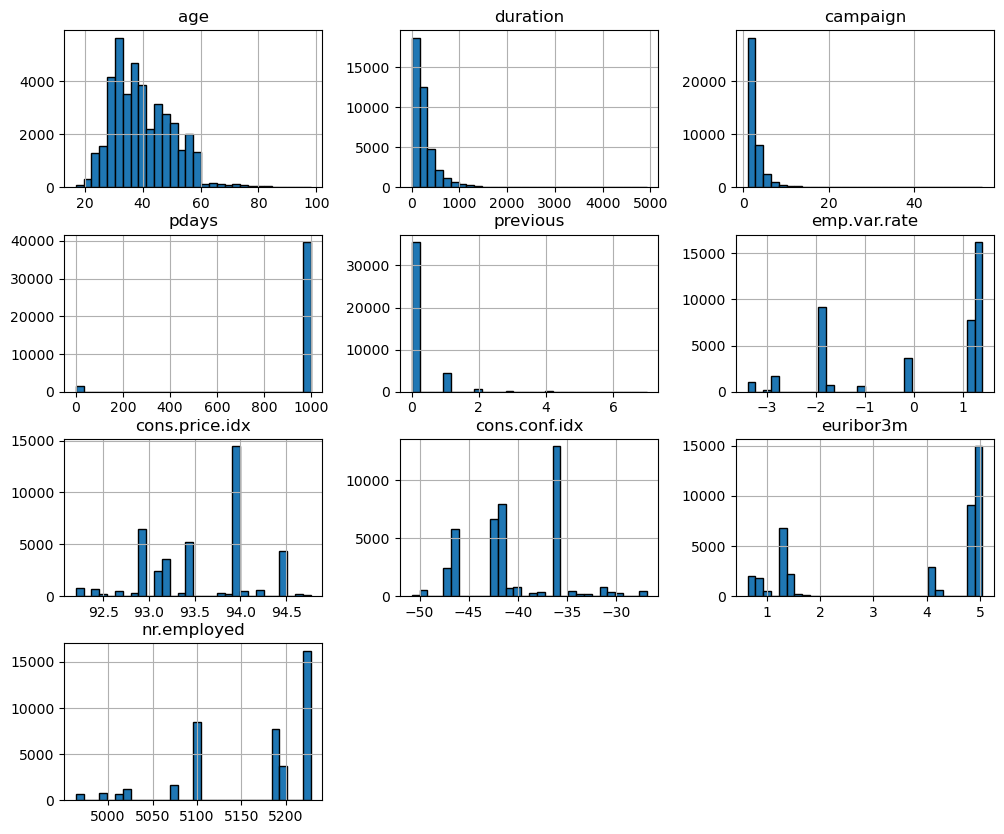

In [51]:
# Histogram distributions of numerical columns
df_bank.hist(figsize=(12, 10), bins=30,  edgecolor='black')
plt.show()

In [52]:
# Reduce skewness by applying log transofrmation
skewed_numvar= ["duration", "campaign", "pdays", "previous"]
for col in skewed_numvar:
    df_bank[col] = np.log1p(df_bank[col])

array([[<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>],
       [<Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>]], dtype=object)

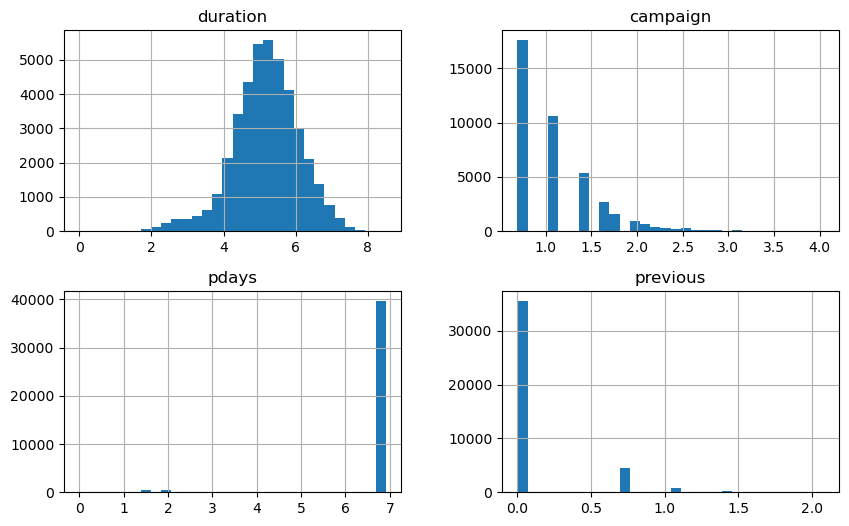

In [53]:
# Verify new histogram distribution
df_bank[skewed_numvar].hist(figsize=(10, 6), bins=30)

In [54]:
# Try square root transformation
df_bank["campaign"] = np.sqrt(df_bank["campaign"])
df_bank["pdays"] = np.sqrt(df_bank["pdays"])
df_bank["previous"] = np.sqrt(df_bank["previous"])

array([[<Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >]], dtype=object)

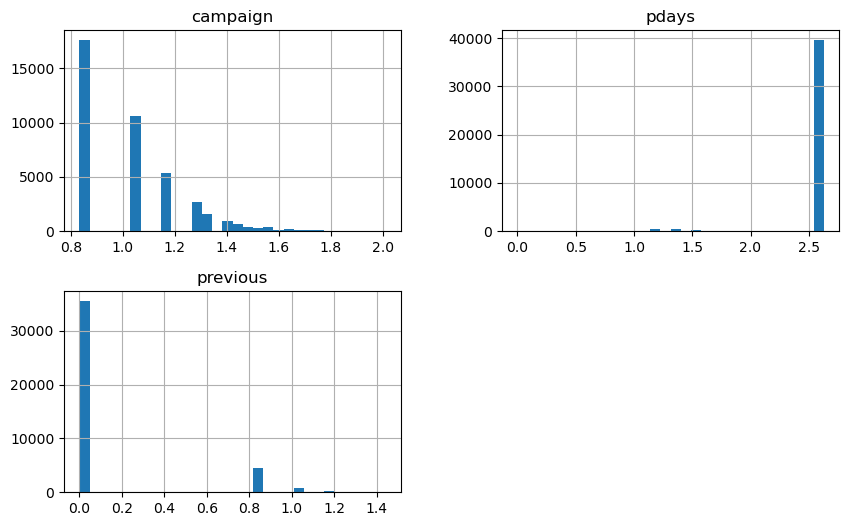

In [55]:
df_bank[["campaign", "pdays", "previous"]].hist(figsize=(10, 6), bins=30)

In [56]:
# Min-Max Scaling to campaign fixed range 0 to 1
scaler = MinMaxScaler()
df_bank["campaign"] = scaler.fit_transform(df_bank[["campaign"]])

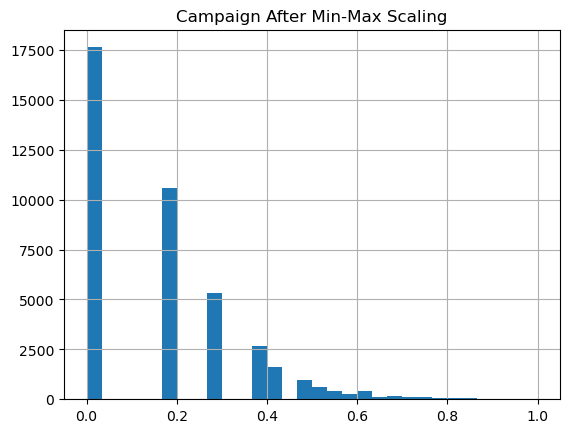

In [57]:
# Check campaign distribution
df_bank["campaign"].hist(bins=30)
plt.title("Campaign After Min-Max Scaling")
plt.show()

In [58]:
# pdays coverted to binary
df_bank["pdays"] = df_bank["pdays"].apply(lambda x: 1 if x > 0 else 0)

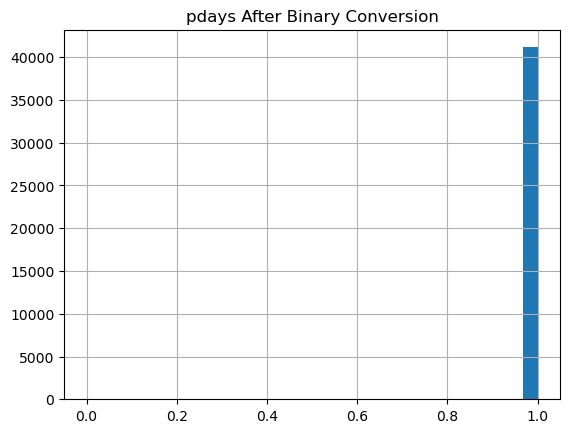

In [59]:
# pdays after conversion 
df_bank["pdays"].hist(bins=30)
plt.title("pdays After Binary Conversion")
plt.show()

In [60]:
# Check previous values
df_bank["previous"].value_counts()

0.000000    35551
0.832555     4561
1.048147      754
1.177410      216
1.268636       70
1.338566       18
1.394959        5
1.442027        1
Name: previous, dtype: int64

In [61]:
# Previous converted to binary 
df_bank["previous"] = df_bank["previous"].apply(lambda x: 1 if x > 0 else 0)

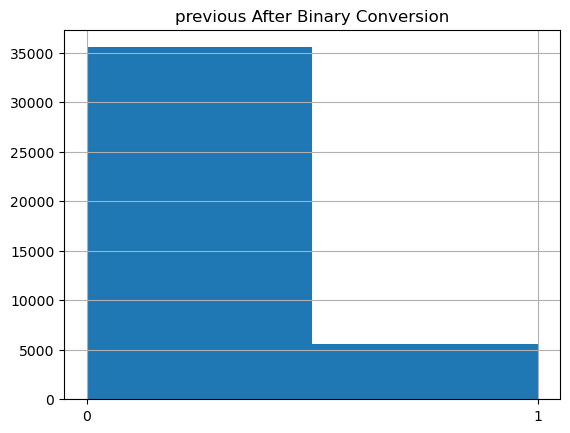

In [62]:
# Previous after conversion
df_bank["previous"].hist(bins=2)
plt.title("previous After Binary Conversion")
plt.xticks([0, 1])                   
plt.show()

In [63]:
# Ensure categorical variables are encoded to numeric
df_bank = pd.get_dummies(df_bank, columns=["job", "education", "poutcome", "month", "day_of_week", "marital"], drop_first=True)

In [64]:
# Recalculate the corr of matrix
corr_matrix = df_bank.corr()
corr_with_duration = df_bank.corr()["duration"].sort_values(ascending=False)
print(corr_with_duration)

C:\Users\Maggy\AppData\Local\Temp\ipykernel_19648\2870678567.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df_bank.corr()
C:\Users\Maggy\AppData\Local\Temp\ipykernel_19648\2870678567.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_with_duration = df_bank.corr()["duration"].sort_values(ascending=False)


duration                         1.000000
poutcome_success                 0.072784
previous                         0.036223
day_of_week_wed                  0.031346
cons.conf.idx                    0.027089
month_dec                        0.026839
day_of_week_tue                  0.024156
job_retired                      0.023542
month_jul                        0.022466
month_may                        0.021099
job_student                      0.020334
month_oct                        0.018905
month_sep                        0.017762
month_mar                        0.010737
job_blue-collar                  0.010077
age                              0.008654
education_unknown                0.007777
marital_unknown                  0.007771
day_of_week_thu                  0.004781
job_services                     0.003848
education_basic.9y               0.003643
education_high.school            0.003331
education_basic.6y               0.002793
job_management                   0

In [65]:
# Select the 10 highest absolute correlations with duration (excluding itself)
top_corr_features = corr_with_duration.abs().sort_values(ascending=False).index[:11]  # Include `duration`
filtered_corr_matrix = df_bank[top_corr_features].corr()

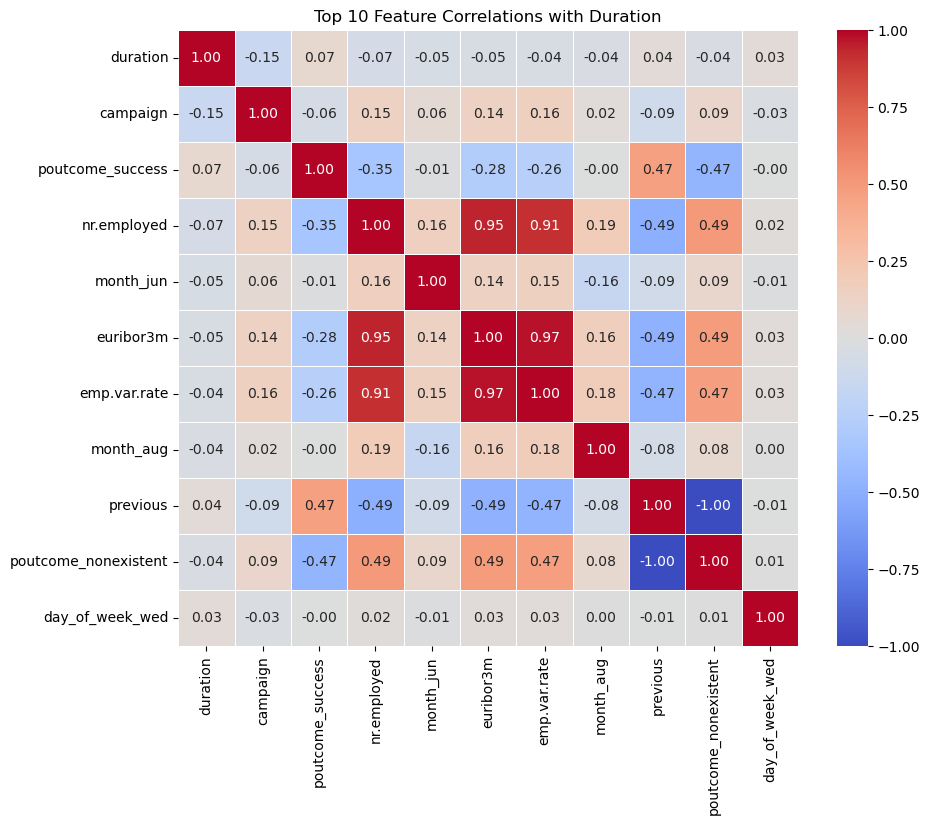

In [66]:
# Plot heatmap for only top correlated features
plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Top 10 Feature Correlations with Duration")
plt.show()

In [67]:
# Feature engineering (create new variables)
df_bank["employment_contact"] = df_bank["nr.employed"] * df_bank["contact"].map({"cellular": 1, "telephone": 0})  
df_bank["duration_squared"] = df_bank["duration"] ** 2  
df_bank["pdays_squared"] = df_bank["pdays"] ** 2  
df_bank["economic_cluster"] = (df_bank["emp.var.rate"] + df_bank["cons.price.idx"] + df_bank["euribor3m"]).round(1)

In [68]:
# Display feature engineering 
df_bank[["employment_contact", "duration_squared", "pdays_squared", "economic_cluster", "previous", "cons.price.idx", "nr.employed"]].head(10)

,employment_contact,duration_squared,pdays_squared,economic_cluster,previous,cons.price.idx,nr.employed
0,0.0,31.006461,1,100.0,0,93.994,5191.0
1,0.0,25.106466,1,100.0,0,93.994,5191.0
2,0.0,29.430083,1,100.0,0,93.994,5191.0
3,0.0,25.239375,1,100.0,0,93.994,5191.0
4,0.0,32.834044,1,100.0,0,93.994,5191.0
5,0.0,28.019076,1,100.0,0,93.994,5191.0
6,0.0,24.419830,1,100.0,0,93.994,5191.0
7,0.0,28.992787,1,100.0,0,93.994,5191.0
8,0.0,35.316864,1,100.0,0,93.994,5191.0
9,0.0,15.459253,1,100.0,0,93.994,5191.0


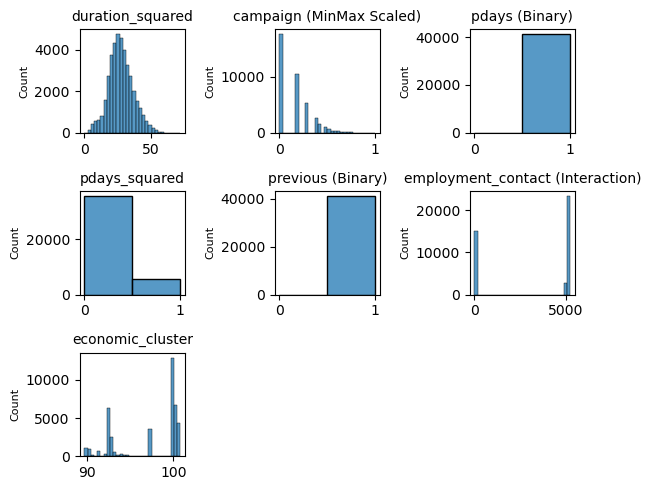

In [69]:
# PLot final histogram (after transformation & feature engineering)
final_features = [
    "duration_squared", "campaign", "pdays", "previous",
    "pdays_squared", "employment_contact", "economic_cluster"
]

display_labels = [
    "duration_squared", 
    "campaign (MinMax Scaled)", 
    "pdays (Binary)",
    "pdays_squared",
    "previous (Binary)", 
    "employment_contact (Interaction)", 
    "economic_cluster", 
]

n_cols = 3
n_rows = (len(final_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 5))

for i, (col, label) in enumerate(zip(final_features, display_labels)):
    row, col_idx = divmod(i, n_cols)
    ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]
    
    bins = 2 if df_bank[col].nunique() == 2 else 30
    sns.histplot(df_bank[col], bins=bins, ax=ax)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.tick_params(axis='both', labelsize=10)

for j in range(i + 1, n_rows * n_cols):
    row, col_idx = divmod(j, n_cols)
    ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]
    ax.axis("off")

plt.tight_layout()
plt.show()

In [70]:
# Train-test split (80:20)
target = "duration"  
features = ["employment_contact", "duration_squared", "pdays_squared", "economic_cluster", "previous", "cons.price.idx", "nr.employed"]

X_regression = df_bank[features]
y_regression = df_bank[target]


X_train, X_test, y_train, y_test = train_test_split(X_regression, y_regression, test_size=0.2, random_state=42)

print(f"Training Set Size: {X_train.shape[0]} samples")
print(f"Test Set Size: {X_test.shape[0]} samples")

Training Set Size: 32940 samples
Test Set Size: 8236 samples


In [71]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42)
}

# Train models
for name, model in models.items():
    model.fit(X_train, y_train)

In [72]:
# Evaluate models
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results.append({"Model": name, "MAE": mae, "MSE": mse, "R² Score": r2})

# Convert to DataFrame
results_df_bank = pd.DataFrame(results)

# Display model performance
print("Model Performance Comparison:")
results_df_bank

Model Performance Comparison:


,Model,MAE,MSE,R² Score
0,Linear Regression,0.086427,0.018607,0.977778
1,Random Forest,0.000056,0.000004,0.999995
2,XGBoost,0.006432,0.001020,0.998782


In [73]:
# Recalculate residuals correctly
residuals = {}  

for name, model in models.items():
    y_pred = model.predict(X_test)  
    residuals[name] = (y_test - y_pred).to_numpy() 

In [74]:
# Backup original residuals
original_residuals = residuals.copy()

In [75]:
# Recalculate residuals
residuals = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    residuals[name] = (y_test - y_pred).to_numpy() 

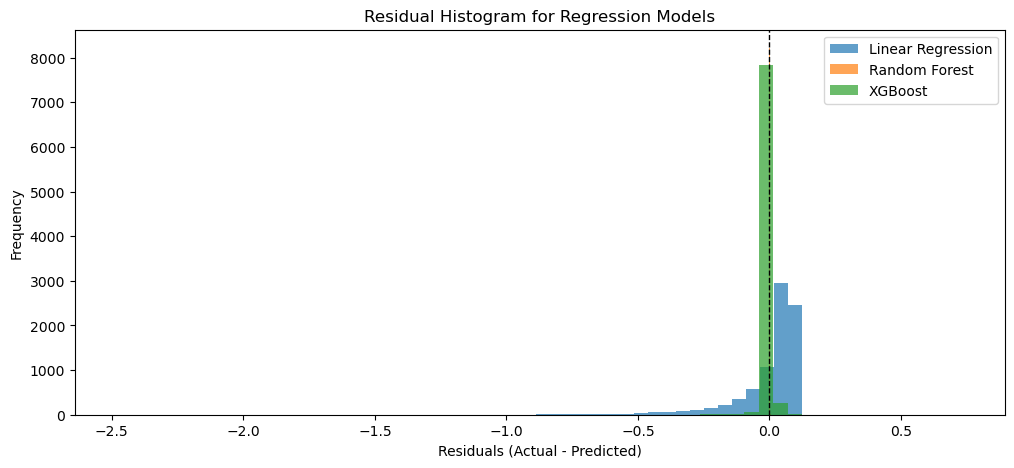

In [76]:
# Plot residuals historgams of Regression Models
plt.figure(figsize=(12, 5))
for name, res in residuals.items():
    plt.hist(res, bins=50, alpha=0.7, label=name)
    
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Residual Histogram for Regression Models")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

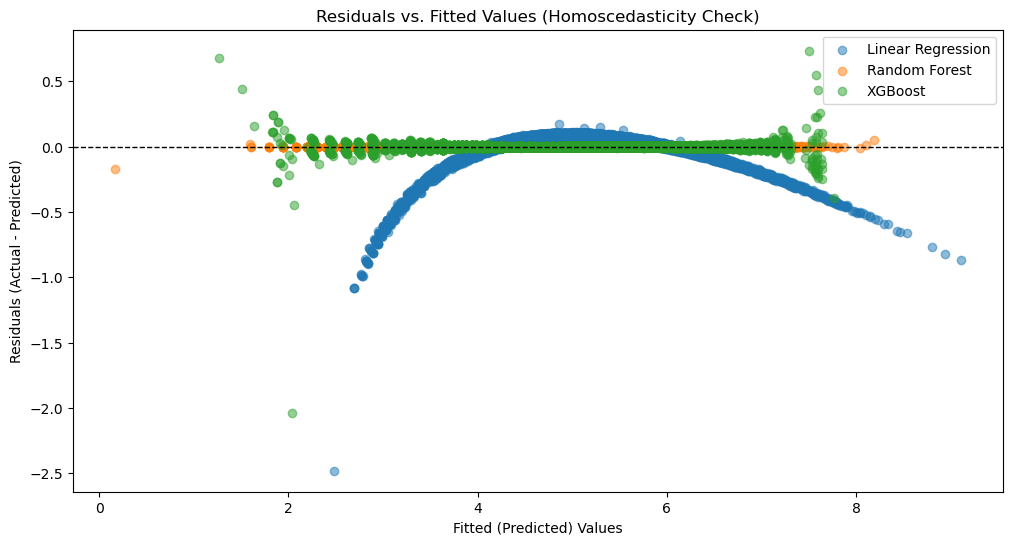

In [77]:
# Plot Residuals vs. Fitted Values of Regression Models
plt.figure(figsize=(12, 6))

for name, model in models.items():
    y_pred = model.predict(X_test)
    res = residuals[name]  

    plt.scatter(y_pred, res, alpha=0.5, label=name)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Residuals vs. Fitted Values (Homoscedasticity Check)")
plt.xlabel("Fitted (Predicted) Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.legend()
plt.show()

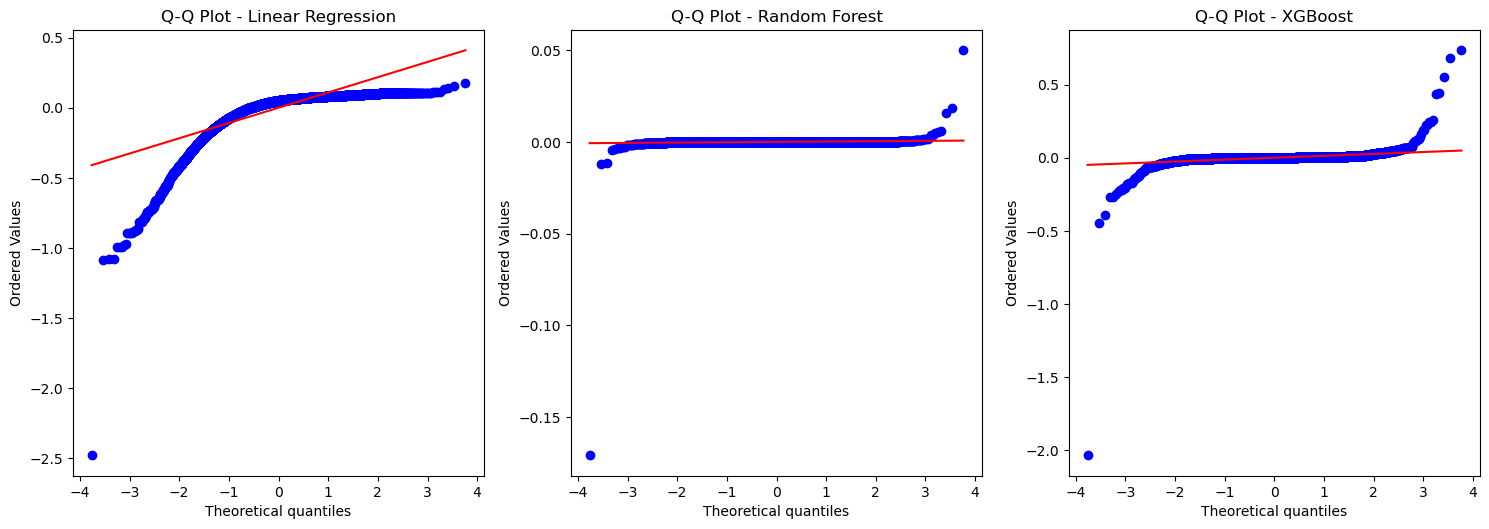

In [78]:
# Q-Q Plot of Regression Models
plt.figure(figsize=(15, 10))

for i, (name, res) in enumerate(residuals.items(), 1):
    plt.subplot(2, 3, i)  
    
    res_array = np.array(res).astype(float)
    
    stats.probplot(res_array, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot - {name}")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

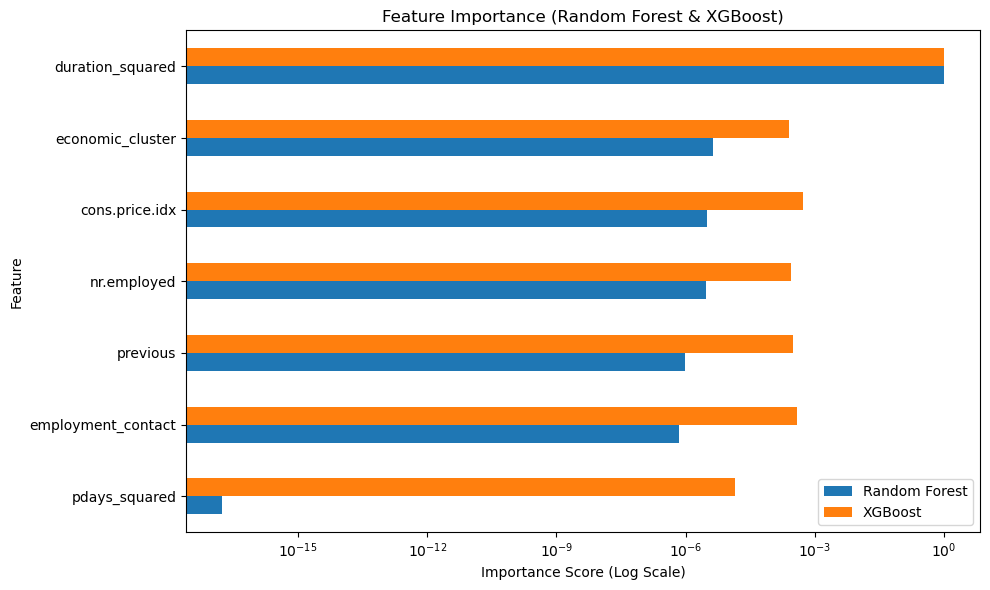

In [79]:
# Extract feature importance (RF & XGBoost)
feature_importance_df_bank = pd.DataFrame()

for name, model in models.items():
    if hasattr(model, "feature_importances_"):
        feature_importance_df_bank[name] = model.feature_importances_

feature_importance_df_bank.index = X_train.columns
feature_importance_df_bank = feature_importance_df_bank.sort_values(by="Random Forest", ascending=True)

plt.figure(figsize=(10, 6))
feature_importance_df_bank.plot(kind="barh", figsize=(10, 6), logx=True)  # Log scale for better visibility
plt.title("Feature Importance (Random Forest & XGBoost)")
plt.xlabel("Importance Score (Log Scale)")
plt.ylabel("Feature")
plt.legend(["Random Forest", "XGBoost"])
plt.tight_layout()
plt.show()

In [80]:
## Classification

In [81]:
# Copy original dataframe for classifcation
df_bank_class = df_bank.copy()

# Encode the target variable y for classification
df_bank_class['y'] = df_bank_class['y'].map({'yes': 1, 'no': 0})

In [82]:
# Select features to use for classification
features = ["employment_contact", "duration_squared", "pdays_squared", "economic_cluster", "previous", "cons.price.idx", "nr.employed"]

X_classification = df_bank_class[features]
y_classification = df_bank_class["y"] 

In [83]:
# Train-test split (80:20)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_classification, y_classification, test_size=0.2, random_state=42, stratify=y_classification)
print(f"Data split complete: {X_train_clf.shape[0]} training samples, {X_test_clf.shape[0]} testing samples.")

Data split complete: 32940 training samples, 8236 testing samples.


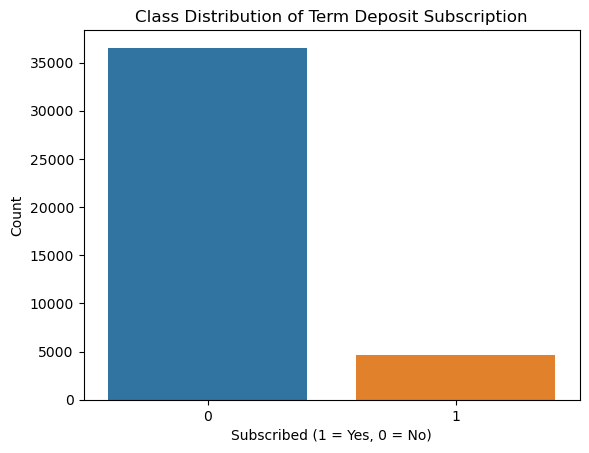

In [84]:
# Plot class distribution
sns.countplot(data=df_bank_class, x='y')
plt.title("Class Distribution of Term Deposit Subscription")
plt.xlabel("Subscribed (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

In [85]:
# Initialize models
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [86]:
# Train models
for name, model in clf_models.items():
    model.fit(X_train_clf, y_train_clf)
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.
XGBoost trained.


C:\Users\Maggy\anaconda 3 file\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:11:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [87]:
# Store model evaluation results
evaluation_results = []

for name, model in clf_models.items():
    y_pred = model.predict(X_test_clf)
    y_proba = model.predict_proba(X_test_clf)[:, 1]  # for ROC-AUC
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred)
    recall = recall_score(y_test_clf, y_pred)
    f1 = f1_score(y_test_clf, y_pred)
    roc_auc = roc_auc_score(y_test_clf, y_proba)

    evaluation_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    })

In [88]:
# Display model evalutaion as DataFrame
results_clf_df_bank = pd.DataFrame(evaluation_results)
print("Model Evaluation Results:")
results_clf_df_bank

Model Evaluation Results:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.904201,0.627523,0.368534,0.464358,0.919715
1,Decision Tree,0.893638,0.531175,0.477371,0.502838,0.735189
2,XGBoost,0.913550,0.630751,0.561422,0.594071,0.943042


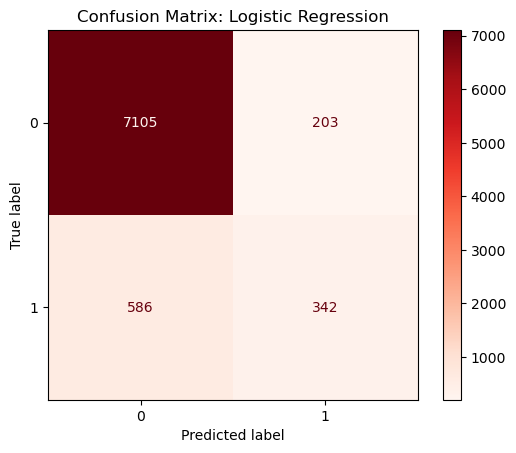

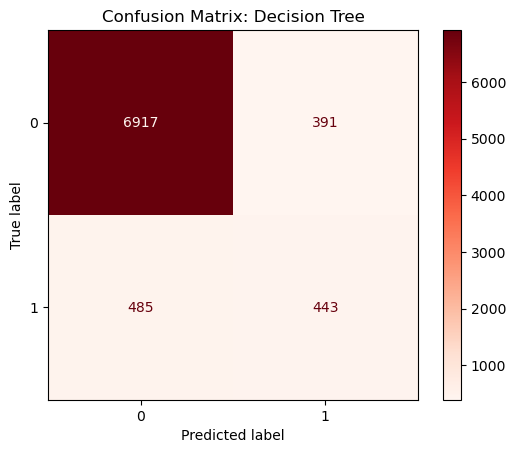

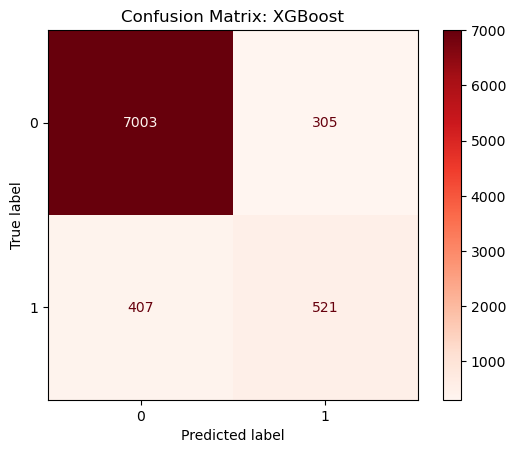

In [89]:
# Plot confusion matrix for each model
for name, model in clf_models.items():
    y_pred = model.predict(X_test_clf)
    cm = confusion_matrix(y_test_clf, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap='Reds')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

In [90]:
# Store confusion matrix values
cmatrix_summary = []

for name, model in clf_models.items():
    y_pred = model.predict(X_test_clf)
    tn, fp, fn, tp = confusion_matrix(y_test_clf, y_pred).ravel()

    cmatrix_summary.append({
        "Model": name,
        "True Negatives (TN)": tn,
        "False Positives (FP)": fp,
        "False Negatives (FN)": fn,
        "True Positives (TP)": tp
    })

In [91]:
# Convert confusion matrix values to DataFrame
cmatrix_df_bank = pd.DataFrame(cmatrix_summary)
cmatrix_df_bank

,Model,True Negatives (TN),False Positives (FP),False Negatives (FN),True Positives (TP)
0,Logistic Regression,7105,203,586,342
1,Decision Tree,6917,391,485,443
2,XGBoost,7003,305,407,521


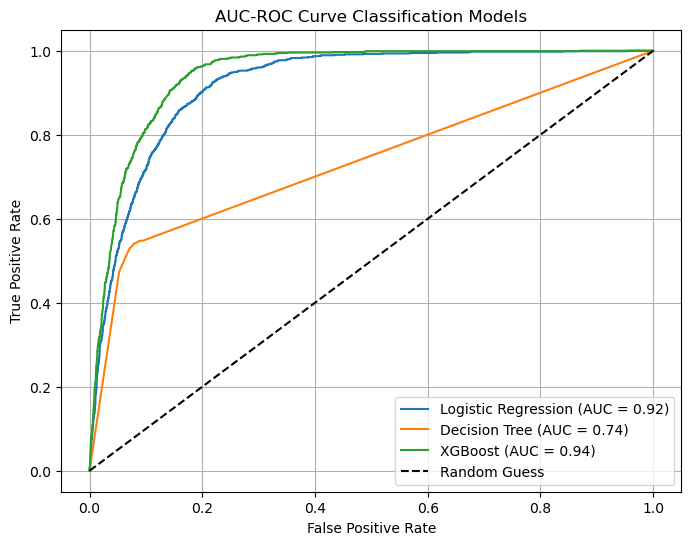

In [92]:
# AUC-ROC curve
plt.figure(figsize=(8, 6))

for name, model in clf_models.items():
    y_proba = model.predict_proba(X_test_clf)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve Classification Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

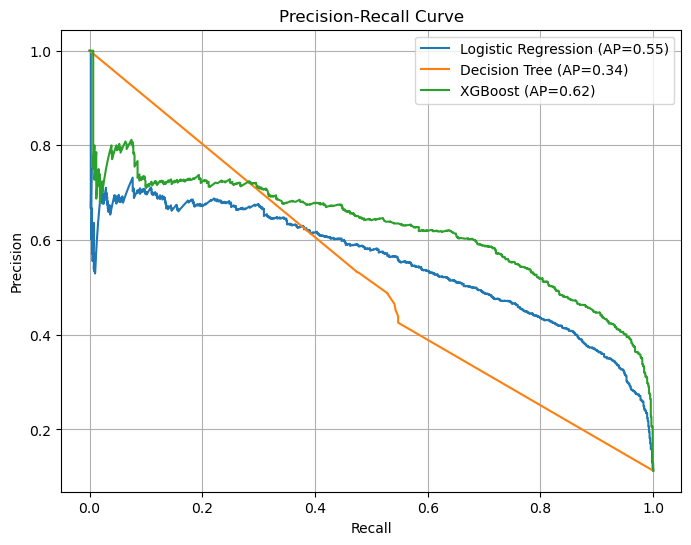

In [93]:
# Precision-recall curve
plt.figure(figsize=(8, 6))
for name, model in clf_models.items():
    y_scores = model.predict_proba(X_test_clf)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test_clf, y_scores)
    avg_precision = average_precision_score(y_test_clf, y_scores)
    plt.plot(recall, precision, label=f"{name} (AP={avg_precision:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

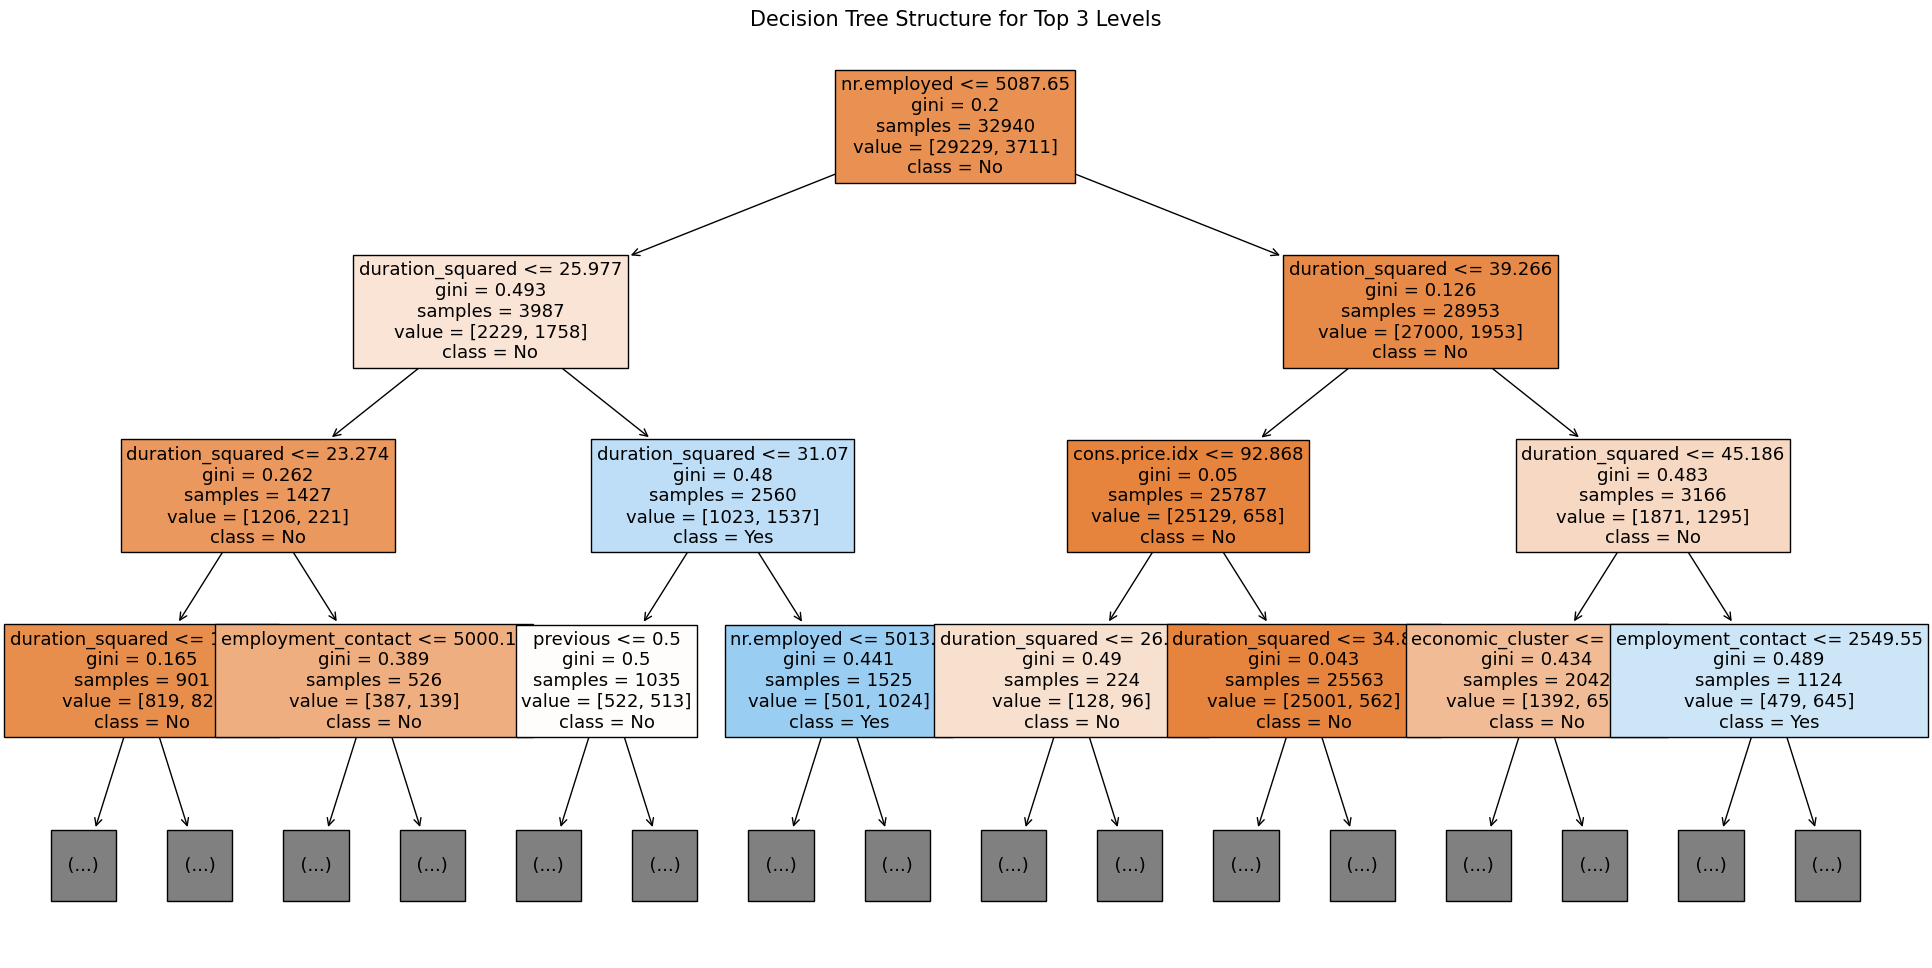

In [94]:
# Decision tree (top 3 leves)
plt.figure(figsize=(24, 12))  
plot_tree(
    clf_models["Decision Tree"], 
    filled=True,
    feature_names=X_train_clf.columns.tolist(),
    class_names=["No", "Yes"],
    max_depth=3,  
    fontsize=13   
)
plt.title("Decision Tree Structure for Top 3 Levels", fontsize=15)
plt.show()